# 🔥 FLAME Pipeline — Classification & Segmentation

**BDS DSC312 — Computer Vision with Multi-modal Models & Analytics**  
**Stage 1: Proof of Concept — Unified Pipeline**

This notebook mirrors the structure of the original FLAME repository (`main.py`) but rebuilt in **PyTorch**.  
Switch between modes using the single `Mode` variable in **Cell 2**.

| Mode | What it does |
|------|-------------|
| `'Train'` | Trains EfficientNet-B0 on training/training/fire + no_fire |
| `'Classification'` | Loads saved checkpoint → evaluates on test/test/fire + no_fire |
| `'Segmentation'` | Trains/evaluates U-Net on segmentation/data/images + masks |

**Dataset folder structure expected:**
```
frames/
├── segmentation/
│   ├── training/
│   │   └── training/
│   │       ├── fire/        ← ~31,500 frames
│   │       └── no_fire/     ← ~7,875 frames
│   └── test/
│       └── test/
│           ├── fire/        ← ~5,763 frames
│           └── no_fire/     ← ~2,854 frames
└── segmentation/
    └── data/
        ├── images/      ← 2,003 RGB frames
        └── masks/       ← 2,003 binary PNG masks
```

In [46]:
!nvidia-smi

Thu Mar 19 15:31:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.59                 Driver Version: 591.59         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:09:00.0  On |                  N/A |
| 50%   39C    P5             42W /  320W |    1218MiB /  10240MiB |     42%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## Cell 1 — Imports & Environment

In [1]:
import os
import random
import warnings
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as models

warnings.filterwarnings('ignore')

# Local fallback transforms used by classification and segmentation cells.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def get_classification_transforms(img_size: int, train: bool = True):
    if train:
        return T.Compose([
            T.Resize(256),
            T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.2),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(img_size),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

class SegmentationAugmenter:
    def __init__(self, img_size: int, seed: int | None = None):
        self.img_size = img_size
        self.rng = random.Random(seed)

    def __call__(self, image: Image.Image, mask: Image.Image, augment: bool = False):
        image = image.convert('RGB')
        mask = mask.convert('L')

        if augment:
            if self.rng.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if self.rng.random() < 0.2:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

        image = TF.resize(image, [self.img_size, self.img_size], antialias=True)
        mask = TF.resize(mask, [self.img_size, self.img_size], interpolation=T.InterpolationMode.NEAREST)

        image_t = TF.to_tensor(image)
        image_t = TF.normalize(image_t, mean=IMAGENET_MEAN, std=IMAGENET_STD)
        mask_t = TF.to_tensor(mask)
        # Masks are encoded as 0/1 in this dataset, so threshold at >0, not >0.5.
        mask_t = (mask_t > 0).float()
        return image_t, mask_t

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.10.0+cpu
Device  : cpu


In [58]:
Mode = 'Segmentation'
print(f'Mode override for current run: {Mode}')

Mode override for current run: Segmentation


---
## Cell 2 — ⚙️ MODE SWITCH  ← Change this cell only !    **REALLY IMPORTANT**

Set `Mode` to one of: `'Train'` | `'Classification'` | `'Segmentation'`

In [2]:
# ╔══════════════════════════════════════════════════════╗
# ║  SET MODE HERE — only this cell needs to change      ║
# ╚══════════════════════════════════════════════════════╝
Mode = 'Train'          # 'Train' | 'Classification' | 'Segmentation'

# ── Paths ───────────────────────────────────────────────────────────────────
# Prefer preprocessed/augmented outputs for classification.
preproc_train_dir = Path('Output/preprocessed_by_class')
preproc_test_dir = Path('Output/preprocessed_test_by_class')
if not preproc_test_dir.exists():
    # Fallback: use train-preprocessed folder for test loader too.
    # For strict evaluation, prepare a dedicated preprocessed test folder and point here.
    preproc_test_dir = preproc_train_dir

CFG = {
    # Classification paths
    'train_dir'  : preproc_train_dir,
    'test_dir'   : preproc_test_dir,

    # Segmentation paths
    'seg_images' : Path('frames/Segmentation/Data/Images'),
    'seg_masks'  : Path('frames/Segmentation/Data/Masks'),

    # Output
    'out_clf'    : Path('Output/Classification'),
    'out_seg'    : Path('Output/Segmentation'),

    # Checkpoints
    'clf_ckpt'   : Path('Output/Classification/best_efficientnet.pth'),
    'seg_ckpt'   : Path('Output/Segmentation/best_unet.pth'),

    # Classification hyperparameters
    'clf_img_size'   : 224,
    'clf_batch_size' : 32,
    'clf_epochs'     : 20,
    'clf_lr'         : 1e-4,
    'clf_early_stop' : 5,
    'clf_classes'    : ['Fire', 'No_Fire'],

    # Segmentation hyperparameters
    'seg_img_size'   : 256,
    'seg_batch_size' : 8,
    'seg_epochs'     : 5,
    'seg_lr'         : 1e-4,
    'seg_early_stop' : 5,
    'seg_train_ratio': 0.80,
    'seg_threshold'  : 0.5,
}

CFG['out_clf'].mkdir(parents=True, exist_ok=True)
CFG['out_seg'].mkdir(parents=True, exist_ok=True)

print(f'Mode    : {Mode}')
print(f'Device  : {DEVICE}')
print(f"Train dir: {CFG['train_dir']}")
print(f"Test dir : {CFG['test_dir']}")

Mode    : Train
Device  : cpu
Train dir: Output\preprocessed_by_class
Test dir : Output\preprocessed_by_class


---
## Cell 3 — Shared Utilities

In [9]:
# ImageNet normalisation constants (used by both tasks)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def denormalise(tensor: torch.Tensor) -> np.ndarray:
    """Convert a normalised image tensor (C,H,W) back to uint8 for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img  = (tensor.cpu() * std + mean).clamp(0, 1)
    return (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)


def plot_loss_curves(history: dict, title: str, save_path: Path):
    """Plot train/val loss and metric curves — required by the rubric."""
    keys  = [k for k in history if k.startswith('train_')]
    n     = len(keys)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, k in zip(axes, keys):
        metric = k.replace('train_', '')
        ax.plot(history[k],                label='Train', color='#e25822')
        ax.plot(history[f'val_{metric}'],  label='Val',   color='#4a90d9')
        ax.set_title(metric.replace('_', ' ').title())
        ax.set_xlabel('Epoch'); ax.legend()
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


print('Shared utilities loaded.')

Shared utilities loaded.


---
## Cell 4 — Classification: Dataset & DataLoaders

Reads the `Training\Training\Fire` / `No_Fire` and `Test\Fire` / `No_Fire` folders directly using `torchvision.datasets.ImageFolder` — no manual indexing needed.

In [3]:
if Mode in ('Train', 'Classification'):

    from torchvision.datasets import ImageFolder

    IMG_SIZE = CFG['clf_img_size']

    transform_train = T.Compose([
        T.Resize(256),
        T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.2),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    transform_val = T.Compose([
        T.Resize(256),
        T.CenterCrop(IMG_SIZE),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    # ── Training set ────────────────────────────────────────────────────────
    train_dataset = ImageFolder(root=str(CFG['train_dir']),
                                transform=transform_train)

    # 80/20 split on training set for validation during training
    n_train = int(0.8 * len(train_dataset))
    n_val   = len(train_dataset) - n_train
    train_subset, val_subset = torch.utils.data.random_split(
        train_dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED))

    # Apply val transforms to the val split
    val_subset.dataset.transform = transform_val

    # ── Test set (held-out, only used in Classification mode) ────────────────
    test_dataset = ImageFolder(root=str(CFG['test_dir']),
                               transform=transform_val)

    train_loader = DataLoader(train_subset, batch_size=CFG['clf_batch_size'],
                               shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_subset,   batch_size=CFG['clf_batch_size'],
                               shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=CFG['clf_batch_size'],
                               shuffle=False, num_workers=2, pin_memory=True)

    # Class mapping — ImageFolder sorts alphabetically: Fire=0, No_Fire=1
    CLASS_NAMES = train_dataset.classes
    print(f'Class mapping   : {train_dataset.class_to_idx}')
    print(f'Train subset    : {len(train_subset):,}')
    print(f'Val   subset    : {len(val_subset):,}')
    print(f'Test  set       : {len(test_dataset):,}')

    # Class imbalance check
    from collections import Counter
    train_labels = [train_dataset.targets[i] for i in train_subset.indices]
    counts = Counter(train_labels)
    print('\nClass counts in training subset:')
    for cls_idx, cnt in sorted(counts.items()):
        print(f'  {CLASS_NAMES[cls_idx]:10s}: {cnt:,}')

    # Compute class weights for imbalanced dataset
    total = sum(counts.values())
    class_weights = torch.tensor(
        [total / (len(counts) * counts[i]) for i in range(len(counts))],
        dtype=torch.float).to(DEVICE)
    print(f'\nClass weights   : {class_weights.tolist()}')

else:
    print(f'Mode = {Mode} — skipping classification data loading.')

Class mapping   : {'Fire': 0, 'No_Fire': 1}
Train subset    : 31,500
Val   subset    : 7,875
Test  set       : 39,375

Class counts in training subset:
  Fire      : 20,033
  No_Fire   : 11,467

Class weights   : [0.7862027883529663, 1.3735065460205078]


---
## Cell 5 — Classification: EfficientNet-B0 Model

EfficientNet-B0 pretrained on ImageNet-1K.  
We replace only the final classifier head — all other weights start from ImageNet.  
This is standard transfer learning and matches the approach in Taxpulat (Stanford 2024).

In [ ]:
if Mode in ('Train', 'Classification'):

    # Load pretrained EfficientNet-B0
    clf_model = models.efficientnet_b0(weights='IMAGENET1K_V1')

    # Freeze all layers first
    for param in clf_model.parameters():
        param.requires_grad = False

    # Replace classifier head — in_features=1280 for EfficientNet-B0
    clf_model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(1280, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(256, 2),      # 2 classes: Fire, No_Fire
    )

    clf_model = clf_model.to(DEVICE)

    # Only the new head is trainable at this stage
    trainable = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in clf_model.parameters())
    print(f'EfficientNet-B0 loaded')
    print(f'Trainable params: {trainable:,} / {total:,}')

    # Loss uses class weights to handle Fire:No_Fire imbalance (~4:1)
    clf_criterion = nn.CrossEntropyLoss(weight=class_weights)
    clf_optimizer = optim.Adam(clf_model.classifier.parameters(),
                                lr=CFG['clf_lr'])
    clf_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        clf_optimizer, mode='min', factor=0.5, patience=3)

    # Smoke test
    dummy = torch.zeros(2, 3, CFG['clf_img_size'], CFG['clf_img_size']).to(DEVICE)
    out   = clf_model(dummy)
    print(f'Forward pass OK : input {dummy.shape} → output {out.shape}')

else:
    print(f'Mode = {Mode} — skipping classification model build.')

EfficientNet-B0 loaded
Trainable params: 328,450 / 4,335,998
Forward pass OK : input torch.Size([2, 3, 224, 224]) → output torch.Size([2, 2])


---
## Cell 6 — Train Mode: Train the Classifier

Phase 1 — training classifier head only


  Epoch 01/1 loss 0.1684/0.0826  acc 0.9435/0.9726
    ✅ Checkpoint saved


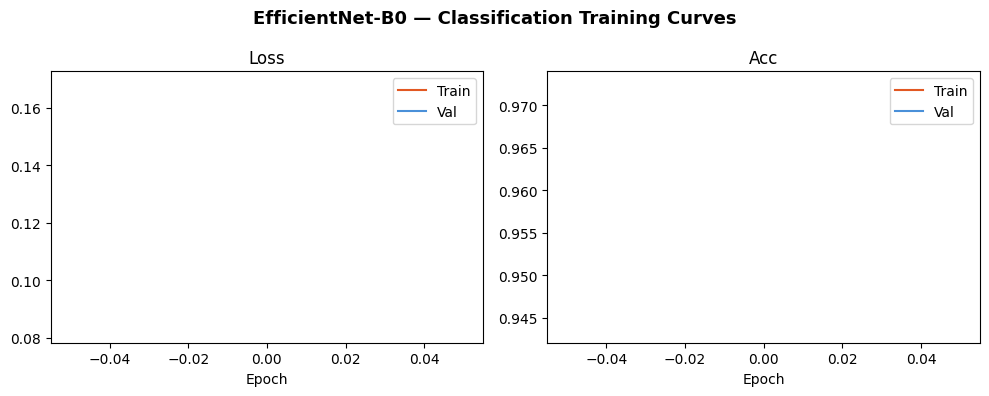

Saved → Output\Classification\clf_training_curves.png

Training complete. Best val_loss = 0.0826


In [ ]:
if Mode == 'Train':

    # Runtime override for faster experiments.
    CFG['clf_epochs'] = 1

    def clf_train_epoch(model, loader, criterion, optimizer, device):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in tqdm(loader, desc='  Train', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
        return total_loss / len(loader), correct / total

    @torch.no_grad()
    def clf_eval_epoch(model, loader, criterion, device):
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in tqdm(loader, desc='  Val  ', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
        return total_loss / len(loader), correct / total

    def build_efficientnet_b0():
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        for p in model.parameters():
            p.requires_grad = False

        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(1280, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, 2),
        )
        model = model.to(DEVICE)

        return {
            'name': 'EfficientNet-B0',
            'model': model,
            'head_params': model.classifier.parameters(),
            'unfreeze_feature_idxs': [6, 7, 8],
            'curve_file': 'clf_training_curves_efficientnet_b0.png',
            'ckpt_path': CFG['out_clf'] / 'best_efficientnet.pth',
        }

    def build_mobilenet_v3_small():
        model = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        for p in model.parameters():
            p.requires_grad = False

        in_features = model.classifier[0].in_features
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, 2),
        )
        model = model.to(DEVICE)

        last_idx = len(model.features) - 1
        return {
            'name': 'MobileNetV3-Small',
            'model': model,
            'head_params': model.classifier.parameters(),
            'unfreeze_feature_idxs': [last_idx - 2, last_idx - 1, last_idx],
            'curve_file': 'clf_training_curves_mobilenet_v3_small.png',
            'ckpt_path': CFG['out_clf'] / 'best_mobilenetv3_small.pth',
        }

    def train_one_classifier(spec):
        model = spec['model']
        model_name = spec['name']

        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.Adam(spec['head_params'], lr=CFG['clf_lr'])
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3)

        history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': []
        }
        best_val_loss, no_improve = float('inf'), 0

        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(f'\n{model_name} loaded')
        print(f'Trainable params: {trainable:,} / {total:,}')

        dummy = torch.zeros(2, 3, CFG['clf_img_size'], CFG['clf_img_size']).to(DEVICE)
        out = model(dummy)
        print(f'Forward pass OK : input {dummy.shape} -> output {out.shape}')

        print(f'\n{model_name} | Phase 1 - training classifier head only')
        phase1_epochs = min(10, CFG['clf_epochs'])

        for epoch in range(1, phase1_epochs + 1):
            tl, ta = clf_train_epoch(model, train_loader, criterion, optimizer, DEVICE)
            vl, va = clf_eval_epoch(model, val_loader, criterion, DEVICE)
            scheduler.step(vl)
            history['train_loss'].append(tl); history['val_loss'].append(vl)
            history['train_acc'].append(ta); history['val_acc'].append(va)
            print(f'  Epoch {epoch:02d}/{phase1_epochs} '
                  f'loss {tl:.4f}/{vl:.4f}  acc {ta:.4f}/{va:.4f}')
            if vl < best_val_loss:
                best_val_loss = vl
                no_improve = 0
                torch.save(
                    {
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_loss': vl,
                        'val_acc': va,
                        'arch': model_name,
                    },
                    spec['ckpt_path'],
                )
                print('    Checkpoint saved')
            else:
                no_improve += 1

        remaining = CFG['clf_epochs'] - phase1_epochs
        if remaining > 0:
            print(f'\n{model_name} | Phase 2 - unfreezing top backbone blocks')
            for name, param in model.named_parameters():
                if any(f'features.{i}' in name for i in spec['unfreeze_feature_idxs']):
                    param.requires_grad = True

            optimizer = optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=CFG['clf_lr'] / 10,
            )

            for epoch in range(phase1_epochs + 1, CFG['clf_epochs'] + 1):
                tl, ta = clf_train_epoch(model, train_loader, criterion, optimizer, DEVICE)
                vl, va = clf_eval_epoch(model, val_loader, criterion, DEVICE)
                history['train_loss'].append(tl); history['val_loss'].append(vl)
                history['train_acc'].append(ta); history['val_acc'].append(va)
                print(f'  Epoch {epoch:02d}/{CFG["clf_epochs"]} '
                      f'loss {tl:.4f}/{vl:.4f}  acc {ta:.4f}/{va:.4f}')
                if vl < best_val_loss:
                    best_val_loss = vl
                    no_improve = 0
                    torch.save(
                        {
                            'epoch': epoch,
                            'model_state_dict': model.state_dict(),
                            'val_loss': vl,
                            'val_acc': va,
                            'arch': model_name,
                        },
                        spec['ckpt_path'],
                    )
                    print('    Checkpoint saved')
                else:
                    no_improve += 1
                    if no_improve >= CFG['clf_early_stop']:
                        print(f'  Early stopping at epoch {epoch}')
                        break

        plot_loss_curves(
            history,
            f'{model_name} - Classification Training Curves',
            CFG['out_clf'] / spec['curve_file'],
        )
        print(f'{model_name} training complete. Best val_loss = {best_val_loss:.4f}')

        return {
            'history': history,
            'best_val_loss': best_val_loss,
            'ckpt': spec['ckpt_path'],
        }

    efficientnet_spec = build_efficientnet_b0()
    run_results = {}
    run_results[efficientnet_spec['name']] = train_one_classifier(efficientnet_spec)

    # Keep existing downstream compatibility for Classification mode.
    CFG['clf_ckpt'] = CFG['out_clf'] / 'best_efficientnet.pth'

else:
    print(f'Mode = {Mode} - skipping EfficientNet training cell.')

---
## Cell 6B - Shared Helpers for Classification Training (No Retrain)

In [4]:
if Mode == 'Train':

    def clf_train_epoch(model, loader, criterion, optimizer, device):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in tqdm(loader, desc='  Train', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
        return total_loss / len(loader), correct / total

    @torch.no_grad()
    def clf_eval_epoch(model, loader, criterion, device):
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in tqdm(loader, desc='  Val  ', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
        return total_loss / len(loader), correct / total

    def build_mobilenet_v3_small():
        model = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        for p in model.parameters():
            p.requires_grad = False

        in_features = model.classifier[0].in_features
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, 2),
        )
        model = model.to(DEVICE)

        last_idx = len(model.features) - 1
        return {
            'name': 'MobileNetV3-Small',
            'model': model,
            'head_params': model.classifier.parameters(),
            'unfreeze_feature_idxs': [last_idx - 2, last_idx - 1, last_idx],
            'curve_file': 'clf_training_curves_mobilenet_v3_small.png',
            'ckpt_path': CFG['out_clf'] / 'best_mobilenetv3_small.pth',
        }

    def train_one_classifier(spec):
        model = spec['model']
        model_name = spec['name']

        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.Adam(spec['head_params'], lr=CFG['clf_lr'])
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3)

        history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': []
        }
        best_val_loss, no_improve = float('inf'), 0

        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(f'\n{model_name} loaded')
        print(f'Trainable params: {trainable:,} / {total:,}')

        dummy = torch.zeros(2, 3, CFG['clf_img_size'], CFG['clf_img_size']).to(DEVICE)
        out = model(dummy)
        print(f'Forward pass OK : input {dummy.shape} -> output {out.shape}')

        phase1_epochs = min(10, CFG['clf_epochs'])
        print(f'\n{model_name} | Phase 1 - training classifier head only')

        for epoch in range(1, phase1_epochs + 1):
            tl, ta = clf_train_epoch(model, train_loader, criterion, optimizer, DEVICE)
            vl, va = clf_eval_epoch(model, val_loader, criterion, DEVICE)
            scheduler.step(vl)
            history['train_loss'].append(tl); history['val_loss'].append(vl)
            history['train_acc'].append(ta); history['val_acc'].append(va)
            print(f'  Epoch {epoch:02d}/{phase1_epochs} '
                  f'loss {tl:.4f}/{vl:.4f}  acc {ta:.4f}/{va:.4f}')
            if vl < best_val_loss:
                best_val_loss = vl
                no_improve = 0
                torch.save(
                    {
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_loss': vl,
                        'val_acc': va,
                        'arch': model_name,
                    },
                    spec['ckpt_path'],
                )
                print('    Checkpoint saved')
            else:
                no_improve += 1

        remaining = CFG['clf_epochs'] - phase1_epochs
        if remaining > 0:
            print(f'\n{model_name} | Phase 2 - unfreezing top backbone blocks')
            for name, param in model.named_parameters():
                if any(f'features.{i}' in name for i in spec['unfreeze_feature_idxs']):
                    param.requires_grad = True

            optimizer = optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=CFG['clf_lr'] / 10,
            )

            for epoch in range(phase1_epochs + 1, CFG['clf_epochs'] + 1):
                tl, ta = clf_train_epoch(model, train_loader, criterion, optimizer, DEVICE)
                vl, va = clf_eval_epoch(model, val_loader, criterion, DEVICE)
                history['train_loss'].append(tl); history['val_loss'].append(vl)
                history['train_acc'].append(ta); history['val_acc'].append(va)
                print(f'  Epoch {epoch:02d}/{CFG["clf_epochs"]} '
                      f'loss {tl:.4f}/{vl:.4f}  acc {ta:.4f}/{va:.4f}')
                if vl < best_val_loss:
                    best_val_loss = vl
                    no_improve = 0
                    torch.save(
                        {
                            'epoch': epoch,
                            'model_state_dict': model.state_dict(),
                            'val_loss': vl,
                            'val_acc': va,
                            'arch': model_name,
                        },
                        spec['ckpt_path'],
                    )
                    print('    Checkpoint saved')
                else:
                    no_improve += 1
                    if no_improve >= CFG['clf_early_stop']:
                        print(f'  Early stopping at epoch {epoch}')
                        break

        plot_loss_curves(
            history,
            f'{model_name} - Classification Training Curves',
            CFG['out_clf'] / spec['curve_file'],
        )
        print(f'{model_name} training complete. Best val_loss = {best_val_loss:.4f}')

        return {
            'history': history,
            'best_val_loss': best_val_loss,
            'ckpt': spec['ckpt_path'],
        }

    if 'run_results' not in globals():
        run_results = {}

    print('Shared training helpers loaded. You can now run MobileNet without rerunning EfficientNet.')

else:
    print(f'Mode = {Mode} - skipping helper setup for classification training.')

Shared training helpers loaded. You can now run MobileNet without rerunning EfficientNet.


---
## Cell 6C - Train Mode: Train MobileNetV3-Small


MobileNetV3-Small loaded
Trainable params: 148,226 / 1,075,234
Forward pass OK : input torch.Size([2, 3, 224, 224]) -> output torch.Size([2, 2])

MobileNetV3-Small | Phase 1 - training classifier head only


  Epoch 01/1 loss 0.1616/0.0866  acc 0.9470/0.9694
    Checkpoint saved


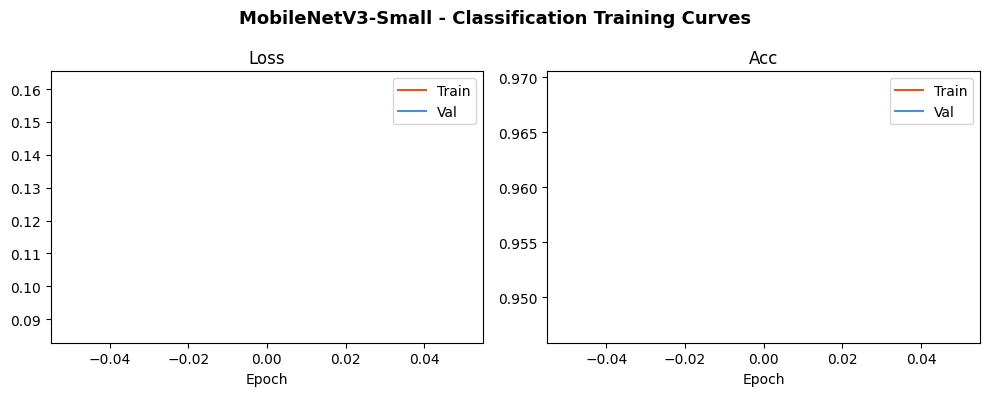

Saved → Output\Classification\clf_training_curves_mobilenet_v3_small.png
MobileNetV3-Small training complete. Best val_loss = 0.0866

  TRAINING SUMMARY (AVAILABLE MODELS)
  MobileNetV3-Small    | best val_loss: 0.0866 | best val_acc: 0.9694 | ckpt: best_mobilenetv3_small.pth


In [73]:
if Mode == 'Train':

    if 'build_mobilenet_v3_small' not in globals() or 'train_one_classifier' not in globals():
        raise RuntimeError(
            'Please run the helper cell above (Cell 6B) first.'
        )

    if 'run_results' not in globals():
        run_results = {}

    mobilenet_spec = build_mobilenet_v3_small()
    run_results[mobilenet_spec['name']] = train_one_classifier(mobilenet_spec)

    print('\n' + '=' * 60)
    print('  TRAINING SUMMARY (AVAILABLE MODELS)')
    print('=' * 60)
    for model_name, result in run_results.items():
        best_acc = max(result['history']['val_acc']) if result['history']['val_acc'] else float('nan')
        print(f'  {model_name:20s} | best val_loss: {result["best_val_loss"]:.4f} '
              f'| best val_acc: {best_acc:.4f} | ckpt: {result["ckpt"].name}')
    print('=' * 60)

    if 'EfficientNet-B0' in run_results and 'MobileNetV3-Small' in run_results:
        plt.figure(figsize=(8, 5))
        plt.plot(run_results['EfficientNet-B0']['history']['val_acc'],
                 marker='o', label='EfficientNet-B0')
        plt.plot(run_results['MobileNetV3-Small']['history']['val_acc'],
                 marker='o', label='MobileNetV3-Small')
        plt.title('Validation Accuracy Comparison: EfficientNet-B0 vs MobileNetV3-Small')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Accuracy')
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        compare_path = CFG['out_clf'] / 'clf_val_acc_comparison_efficientnet_vs_mobilenetv3_small.png'
        plt.savefig(compare_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved comparison plot -> {compare_path}')

else:
    print(f'Mode = {Mode} - skipping MobileNetV3-Small training cell.')

---
## Cell 6D - Shared Helper for Xception (No Retrain)

In [5]:
if Mode == 'Train':

    def build_xception():
        model = None

        # Prefer torchvision if available in this environment.
        if hasattr(models, 'xception'):
            try:
                model = models.xception(weights='IMAGENET1K_V1')
            except Exception:
                model = models.xception(weights=None)

        # Fallback to timm when torchvision xception is unavailable.
        if model is None:
            try:
                import timm
            except Exception as exc:
                raise RuntimeError(
                    "Xception is not available in torchvision on this setup. "
                    "Install timm first: pip install timm"
                ) from exc
            model = timm.create_model('xception', pretrained=True)

        for p in model.parameters():
            p.requires_grad = False

        if hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
            in_features = model.fc.in_features
            model.fc = nn.Sequential(
                nn.Dropout(p=0.2),
                nn.Linear(in_features, 256),
                nn.ReLU(inplace=True),
                nn.Dropout(p=0.2),
                nn.Linear(256, 2),
            )
            head_params = model.fc.parameters()

        elif hasattr(model, 'classifier'):
            clf = model.classifier
            if isinstance(clf, nn.Linear):
                in_features = clf.in_features
                model.classifier = nn.Sequential(
                    nn.Dropout(p=0.2),
                    nn.Linear(in_features, 256),
                    nn.ReLU(inplace=True),
                    nn.Dropout(p=0.2),
                    nn.Linear(256, 2),
                )
            elif isinstance(clf, nn.Sequential):
                linears = [m for m in clf if isinstance(m, nn.Linear)]
                if not linears:
                    raise RuntimeError('Could not find Linear layer in classifier for Xception head replacement.')
                in_features = linears[-1].in_features
                model.classifier = nn.Sequential(
                    nn.Dropout(p=0.2),
                    nn.Linear(in_features, 256),
                    nn.ReLU(inplace=True),
                    nn.Dropout(p=0.2),
                    nn.Linear(256, 2),
                )
            else:
                raise RuntimeError('Unsupported classifier type for Xception model.')
            head_params = model.classifier.parameters()

        else:
            raise RuntimeError('Unable to locate classifier head in Xception model.')

        model = model.to(DEVICE)

        return {
            'name': 'Xception',
            'model': model,
            'head_params': head_params,
            # For Xception naming, keep phase-2 conservative; head-only if no feature pattern matches.
            'unfreeze_feature_idxs': [],
            'curve_file': 'clf_training_curves_xception.png',
            'ckpt_path': CFG['out_clf'] / 'best_xception.pth',
        }

    print('Xception helper loaded. You can now run the Xception training cell.')

else:
    print(f'Mode = {Mode} - skipping Xception helper setup.')

Xception helper loaded. You can now run the Xception training cell.


---
## Cell 6E - Train Mode: Train Xception

In [6]:
if Mode == 'Train':

    if 'build_xception' not in globals() or 'train_one_classifier' not in globals():
        raise RuntimeError(
            'Please run Cell 6B and Cell 6D first (shared classifier helpers + Xception helper).'
        )

    if 'run_results' not in globals():
        run_results = {}

    xception_spec = build_xception()
    run_results[xception_spec['name']] = train_one_classifier(xception_spec)

    print('\n' + '=' * 60)
    print('  TRAINING SUMMARY (AVAILABLE MODELS)')
    print('=' * 60)
    for model_name, result in run_results.items():
        best_acc = max(result['history']['val_acc']) if result['history']['val_acc'] else float('nan')
        print(f'  {model_name:20s} | best val_loss: {result["best_val_loss"]:.4f} '
              f'| best val_acc: {best_acc:.4f} | ckpt: {result["ckpt"].name}')
    print('=' * 60)

    if len(run_results) >= 2:
        plt.figure(figsize=(9, 5))
        for model_name, result in run_results.items():
            plt.plot(result['history']['val_acc'], marker='o', label=model_name)
        plt.title('Validation Accuracy Comparison Across Trained Classifiers')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Accuracy')
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        compare_path = CFG['out_clf'] / 'clf_val_acc_comparison_all_models.png'
        plt.savefig(compare_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved comparison plot -> {compare_path}')

else:
    print(f'Mode = {Mode} - skipping Xception training cell.')

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to C:\Users\NVIDIA3080/.cache\torch\hub\checkpoints\xception-43020ad28.pth

Xception loaded
Trainable params: 525,058 / 21,332,010
Forward pass OK : input torch.Size([2, 3, 224, 224]) -> output torch.Size([2, 2])

Xception | Phase 1 - training classifier head only


  Epoch 01/10 loss 0.2094/0.1236  acc 0.9369/0.9655
    Checkpoint saved


  Epoch 02/10 loss 0.1365/0.0968  acc 0.9549/0.9721
    Checkpoint saved


  Epoch 03/10 loss 0.1162/0.0833  acc 0.9610/0.9749
    Checkpoint saved


  Epoch 04/10 loss 0.1052/0.0718  acc 0.9635/0.9770
    Checkpoint saved


  Epoch 05/10 loss 0.0944/0.0672  acc 0.9665/0.9797
    Checkpoint saved


KeyboardInterrupt: 

---
## Cell 7 — Classification Mode: Evaluate on Test Set

Loads the best checkpoint and runs full evaluation:  
accuracy, precision, recall, F1, confusion matrix, and ROC curve.

Loaded checkpoint from epoch 1 (val_loss=0.0519, val_acc=0.9832)


Evaluating:   0%|          | 0/1231 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 1231/1231 [19:15<00:00,  1.07it/s]



=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

        Fire     0.9863    0.9869    0.9866     25018
     No_Fire     0.9772    0.9760    0.9766     14357

    accuracy                         0.9830     39375
   macro avg     0.9817    0.9815    0.9816     39375
weighted avg     0.9830    0.9830    0.9830     39375



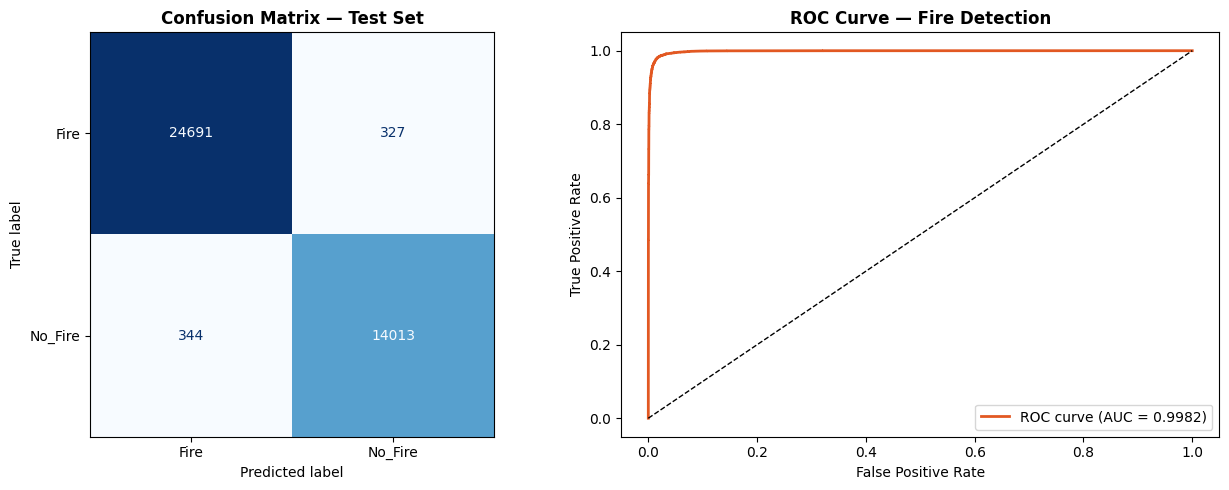

Saved → Output\Classification\clf_evaluation.png


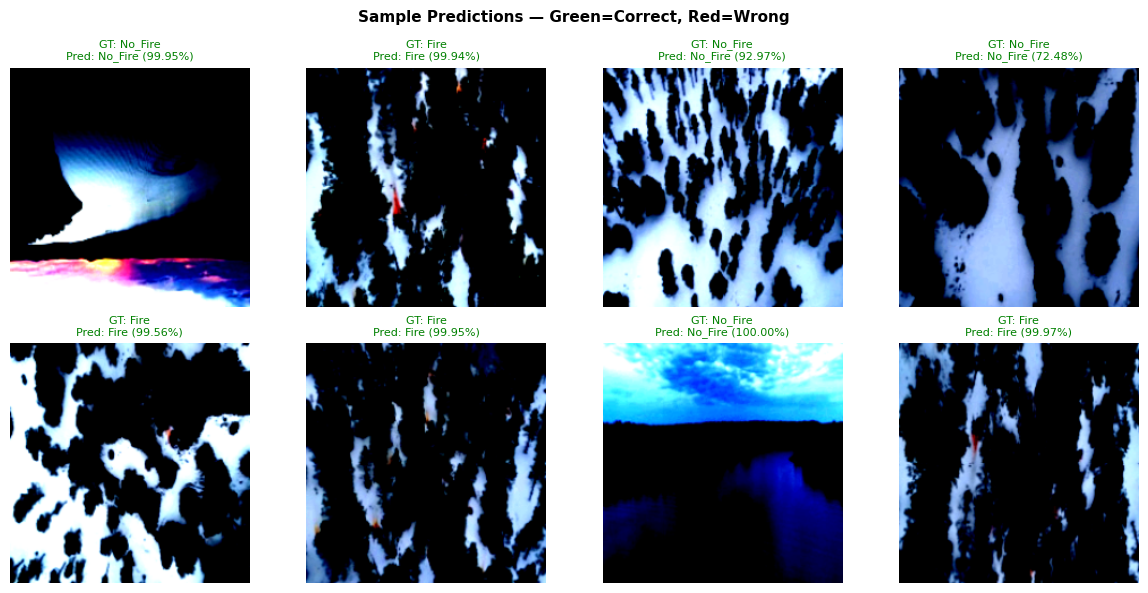

Saved → Output\Classification\clf_sample_predictions.png

  CLASSIFICATION EVALUATION SUMMARY
  Test accuracy   : 0.9830 (98.3%)
  ROC AUC         : 0.9982
  Published baseline (Shamsoshoara 2021): 76% accuracy


In [ ]:
if Mode == 'Classification':

    # ── Load best checkpoint ────────────────────────────────────────────────
    assert CFG['clf_ckpt'].exists(), (
        f"Checkpoint not found: {CFG['clf_ckpt']}\n"
        "Run Mode='Train' first to generate it.")

    ckpt = torch.load(CFG['clf_ckpt'], map_location=DEVICE)
    clf_model.load_state_dict(ckpt['model_state_dict'])
    clf_model.eval()
    print(f"Loaded checkpoint from epoch {ckpt['epoch']} "
          f"(val_loss={ckpt['val_loss']:.4f}, val_acc={ckpt['val_acc']:.4f})")

    # ── Collect all predictions and labels ─────────────────────────────────
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc='Evaluating'):
            imgs = imgs.to(DEVICE)
            logits = clf_model(imgs)
            probs  = torch.softmax(logits, dim=1)[:, 0]  # P(Fire)
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    # ── Classification report ───────────────────────────────────────────────
    print('\n=== Classification Report (Test Set) ===')
    print(classification_report(all_labels, all_preds,
                                 target_names=CLASS_NAMES, digits=4))

    # ── Confusion matrix ────────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=CLASS_NAMES)
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold')

    # ── ROC curve ───────────────────────────────────────────────────────────
    # Fire = class 0 in ImageFolder (alphabetical), so label=0 is positive
    fire_label = CLASS_NAMES.index('Fire')
    binary_labels = (all_labels == fire_label).astype(int)
    fpr, tpr, _ = roc_curve(binary_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='#1f77b4', lw=2,
                  label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve — Fire Detection', fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    save_path = CFG['out_clf'] / 'clf_evaluation.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')

    # ── Sample prediction grid ──────────────────────────────────────────────
    n_show = 8
    sample_indices = random.sample(range(len(test_dataset)), n_show)
    fig, axes = plt.subplots(2, n_show // 2, figsize=(n_show // 2 * 3, 6))
    axes = axes.flatten()

    clf_model.eval()
    with torch.no_grad():
        for ax, idx in zip(axes, sample_indices):
            img_t, true_lbl = test_dataset[idx]
            logit = clf_model(img_t.unsqueeze(0).to(DEVICE))
            pred  = logit.argmax(1).item()
            conf  = torch.softmax(logit, 1).max().item()
            ax.imshow(denormalise(img_t))
            colour = 'green' if pred == true_lbl else 'red'
            ax.set_title(
                f'GT: {CLASS_NAMES[true_lbl]}\n'
                f'Pred: {CLASS_NAMES[pred]} ({conf:.2%})',
                fontsize=8)
            ax.axis('off')

    plt.suptitle('Sample Predictions', fontsize=11, fontweight='bold')
    plt.tight_layout()
    save_path2 = CFG['out_clf'] / 'clf_sample_predictions.png'
    plt.savefig(save_path2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path2}')

    # ── Summary ─────────────────────────────────────────────────────────────
    acc = (all_preds == all_labels).mean()
    print('\n' + '='*50)
    print('  CLASSIFICATION EVALUATION SUMMARY')
    print('='*50)
    print(f'  Test accuracy   : {acc:.4f} ({acc*100:.1f}%)')
    print(f'  ROC AUC         : {roc_auc:.4f}')
    print(f'  Published baseline (Shamsoshoara 2021): 76% accuracy')
    print('='*50)

else:
    print(f'Mode = {Mode} — skipping Classification evaluation.')

---
## Cell 8 — Segmentation Mode: Dataset

Pairs every `.jpg` frame with its `.png` mask by matching filename stems.  
Synchronised augmentation is applied to both image and mask with the same random state.

In [ ]:
if Mode == 'Segmentation':

    class FlameSegDataset(Dataset):
        """Torch dataset for FLAME segmentation.

        Uses `SegmentationAugmenter` to keep
        image/mask transforms synchronized.
        """
        def __init__(self, pairs, img_size, augment=False, seed=None):
            self.pairs = pairs
            self.augmenter = SegmentationAugmenter(img_size, seed=seed)
            self.augment = augment
            self.to_tensor = T.Compose([
                T.ToTensor(),
                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
            ])

        def __len__(self):
            return len(self.pairs)

        def __getitem__(self, idx):
            img_p, msk_p = self.pairs[idx]
            image = Image.open(img_p).convert('RGB').resize(
                (self.w, self.h), Image.BILINEAR)
            mask  = Image.open(msk_p).convert('L').resize(
                (self.w, self.h), Image.NEAREST)

            if self.augment:
                if random.random() > 0.5:
                    image = TF.hflip(image); mask = TF.hflip(mask)
                if random.random() > 0.5:
                    image = TF.vflip(image); mask = TF.vflip(mask)
                if random.random() > 0.3:
                    angle = random.uniform(-15, 15)
                    image = TF.rotate(image, angle)
                    mask  = TF.rotate(mask,  angle)
                image = T.ColorJitter(
                    brightness=0.3, contrast=0.3, saturation=0.2)(image)

            image = self.to_tensor(image)
            mask  = torch.from_numpy(
                (np.array(mask) > 127).astype(np.float32)).unsqueeze(0)
            return image, mask

    # Build paired index
    img_map  = {p.stem: p for p in sorted(CFG['seg_images'].glob('*.jpg'))}
    msk_map  = {p.stem: p for p in sorted(CFG['seg_masks'].glob('*.png'))
                if not p.name.startswith('.')}
    common   = sorted(img_map.keys() & msk_map.keys())
    all_pairs = [(img_map[k], msk_map[k]) for k in common]

    random.seed(SEED)
    random.shuffle(all_pairs)
    n_train = int(len(all_pairs) * CFG['seg_train_ratio'])
    SEG_H = CFG['seg_img_size']

    seg_train_ds = FlameSegDataset(all_pairs[:n_train], SEG_H, augment=True, seed=SEED)
    seg_val_ds   = FlameSegDataset(all_pairs[n_train:], SEG_H, augment=False, seed=SEED)

    num_workers = 0 if os.name == 'nt' else 2
    seg_train_loader = DataLoader(seg_train_ds, batch_size=CFG['seg_batch_size'],
                                   shuffle=True,  num_workers=num_workers, pin_memory=True)
    seg_val_loader   = DataLoader(seg_val_ds,   batch_size=CFG['seg_batch_size'],
                                   shuffle=False, num_workers=num_workers, pin_memory=True)

    print(f'Segmentation source  : {CFG["seg_images"].resolve()}')
    print(f'Masks source         : {CFG["seg_masks"].resolve()}')
    print(f'Total paired samples : {len(all_pairs)}')
    print(f'Train / Val split    : {len(seg_train_ds)} / {len(seg_val_ds)}')

    # Shape check
    i, m = next(iter(seg_train_loader))
    print(f'Image batch : {i.shape}  Mask batch : {m.shape}')
    print(f'Mask unique : {m.unique().tolist()}')

else:
    print(f'Mode = {Mode} — skipping segmentation data loading.')

Rebuilding augmented set because existing masks are empty or rebuild was requested.
Augmented 200/404 source pairs...
Augmented 400/404 source pairs...
Created 808 image/mask pairs in C:\Users\NVIDIA3080\Desktop\Computer Vision class\BushFire-Detection\Output\Segmentation_Augmented
Segmentation source  : C:\Users\NVIDIA3080\Desktop\Computer Vision class\BushFire-Detection\Output\Segmentation_Augmented\Images
Masks source         : C:\Users\NVIDIA3080\Desktop\Computer Vision class\BushFire-Detection\Output\Segmentation_Augmented\Masks
Total paired samples : 808
Train / Val split    : 646 / 162
Image batch : torch.Size([8, 3, 256, 256])  Mask batch : torch.Size([8, 1, 256, 256])
Mask unique : [0.0, 1.0]


---
## Cell 9 — Segmentation Mode: U-Net Architecture

Direct PyTorch translation of `model_unet_kaggle()` from the original `segmentation.py`.

In [60]:
if Mode == 'Segmentation':

    class ConvBlock(nn.Module):
        """Conv→ELU→Dropout→Conv→ELU — one encoder/decoder block."""
        def __init__(self, in_ch, out_ch, drop=0.1):
            super().__init__()
            self.block = nn.Sequential(
                nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
                nn.ELU(inplace=True),
                nn.Dropout2d(drop),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.ELU(inplace=True),
            )
            for m in self.block.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

        def forward(self, x): return self.block(x)

    class UNet(nn.Module):
        """
        U-Net (Ronneberger et al. 2015) — binary fire segmentation.
        Architecture: 5-level encoder-decoder with skip connections.
        Filters: 16 → 32 → 64 → 128 → 256 (bottleneck)
        """
        def __init__(self):
            super().__init__()
            self.enc1 = ConvBlock(3,   16,  0.1)
            self.enc2 = ConvBlock(16,  32,  0.1)
            self.enc3 = ConvBlock(32,  64,  0.2)
            self.enc4 = ConvBlock(64,  128, 0.2)
            self.pool = nn.MaxPool2d(2)
            self.bot  = ConvBlock(128, 256, 0.3)
            self.up6  = nn.ConvTranspose2d(256, 128, 2, stride=2)
            self.dec6 = ConvBlock(256, 128, 0.2)
            self.up7  = nn.ConvTranspose2d(128, 64,  2, stride=2)
            self.dec7 = ConvBlock(128, 64,  0.2)
            self.up8  = nn.ConvTranspose2d(64,  32,  2, stride=2)
            self.dec8 = ConvBlock(64,  32,  0.1)
            self.up9  = nn.ConvTranspose2d(32,  16,  2, stride=2)
            self.dec9 = ConvBlock(32,  16,  0.1)
            self.out  = nn.Sequential(
                nn.Conv2d(16, 1, 1), nn.Sigmoid())

        def forward(self, x):
            c1 = self.enc1(x);          p1 = self.pool(c1)
            c2 = self.enc2(p1);         p2 = self.pool(c2)
            c3 = self.enc3(p2);         p3 = self.pool(c3)
            c4 = self.enc4(p3);         p4 = self.pool(c4)
            c5 = self.bot(p4)
            c6 = self.dec6(torch.cat([self.up6(c5), c4], 1))
            c7 = self.dec7(torch.cat([self.up7(c6), c3], 1))
            c8 = self.dec8(torch.cat([self.up8(c7), c2], 1))
            c9 = self.dec9(torch.cat([self.up9(c8), c1], 1))
            return self.out(c9)

    # ── Loss: BCE + Dice ────────────────────────────────────────────────────
    class BCEDiceLoss(nn.Module):
        def __init__(self, smooth=1e-6):
            super().__init__()
            self.bce = nn.BCELoss()
            self.smooth = smooth
        def forward(self, p, t):
            bce  = self.bce(p, t)
            pf, tf = p.view(-1), t.view(-1)
            inter = (pf * tf).sum()
            dice = 1 - (2*inter + self.smooth) / (pf.sum() + tf.sum() + self.smooth)
            return 0.5 * bce + 0.5 * dice

    def seg_metrics(pred, target, thr=0.5):
        pb = (pred > thr).float(); t = target.float()
        tp = (pb*t).sum().item();   fp = (pb*(1-t)).sum().item()
        fn = ((1-pb)*t).sum().item(); tn = ((1-pb)*(1-t)).sum().item()
        eps = 1e-8
        return {
            'iou'      : tp / (tp+fp+fn+eps),
            'f1'       : 2*tp / (2*tp+fp+fn+eps),
            'precision': tp / (tp+fp+eps),
            'recall'   : tp / (tp+fn+eps),
            'accuracy' : (tp+tn) / (tp+tn+fp+fn+eps),
        }

    seg_model     = UNet().to(DEVICE)
    seg_criterion = BCEDiceLoss()
    seg_optimizer = optim.Adam(seg_model.parameters(), lr=CFG['seg_lr'])
    seg_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        seg_optimizer, mode='min', factor=0.5, patience=3)

    total = sum(p.numel() for p in seg_model.parameters())
    print(f'U-Net parameters: {total:,}')
    dummy = torch.zeros(1, 3, SEG_H, SEG_H).to(DEVICE)
    print(f'Forward pass: {dummy.shape} → {seg_model(dummy).shape}  ✅')

else:
    print(f'Mode = {Mode} — skipping segmentation model build.')

U-Net parameters: 1,939,633
Forward pass: torch.Size([1, 3, 256, 256]) → torch.Size([1, 1, 256, 256])  ✅


---
## Cell 10 — Segmentation Mode: Train U-Net & Evaluate

Training U-Net — 5 epochs on cpu



Epoch 01/5  loss=0.1547/0.1403  IoU=0.5693/0.5966  F1=0.7236/0.7458
  Checkpoint saved


Epoch 02/5  loss=0.1439/0.1313  IoU=0.5921/0.6153  F1=0.7425/0.7610
  Checkpoint saved


Epoch 03/5  loss=0.1412/0.1216  IoU=0.5983/0.6387  F1=0.7463/0.7787
  Checkpoint saved


Epoch 04/5  loss=0.1285/0.1135  IoU=0.6260/0.6589  F1=0.7691/0.7937
  Checkpoint saved


Epoch 05/5  loss=0.1232/0.1128  IoU=0.6390/0.6617  F1=0.7786/0.7957
  Checkpoint saved


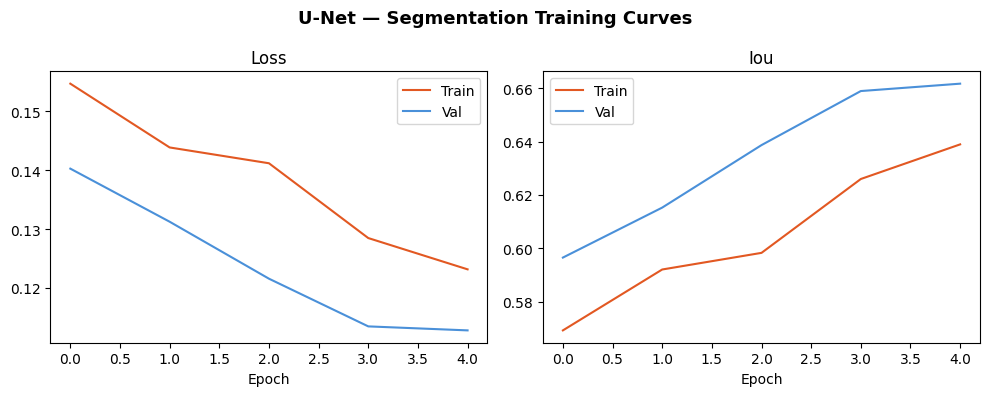

Saved → Output\Segmentation\seg_training_curves.png



=== U-Net Final Validation Metrics ===
  iou         : 0.6617  (66.2%)
  f1          : 0.7957  (79.6%)
  precision   : 0.7881  (78.8%)
  recall      : 0.8055  (80.5%)
  accuracy    : 0.9973  (99.7%)


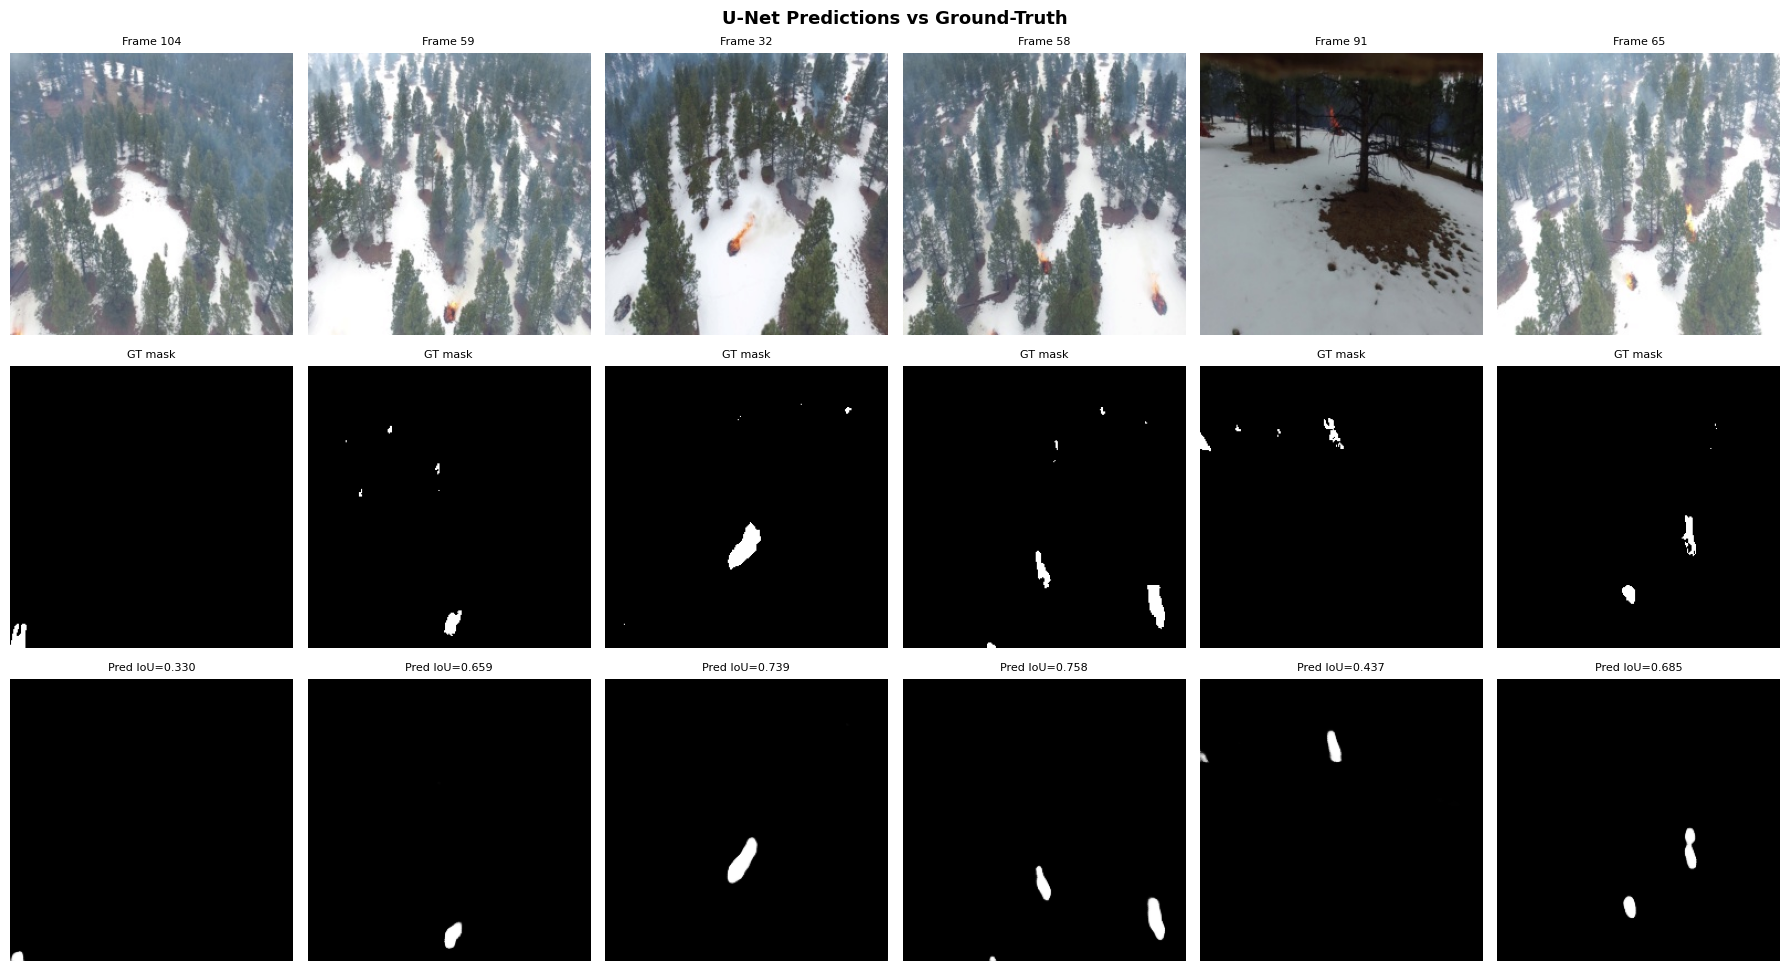

Saved → Output\Segmentation\seg_predictions.png

  SEGMENTATION EVALUATION SUMMARY
  iou         : 66.2%
  f1          : 79.6%
  precision   : 78.8%
  recall      : 80.5%
  accuracy    : 99.7%
  Published baseline (Shamsoshoara 2021):
    Precision: 92%   Recall: 84%


In [ ]:
if Mode == 'Segmentation':

    def seg_epoch(model, loader, criterion, optimizer, device, train=True):
        model.train() if train else model.eval()
        tot_loss = 0.0
        agg = {'iou':0,'f1':0,'precision':0,'recall':0,'accuracy':0}
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for imgs, masks in tqdm(loader,
                    desc='  Train' if train else '  Val  ', leave=False):
                imgs, masks = imgs.to(device), masks.to(device)
                if train: optimizer.zero_grad()
                preds = model(imgs)
                loss  = criterion(preds, masks)
                if train: loss.backward(); optimizer.step()
                tot_loss += loss.item()
                m = seg_metrics(preds.detach(), masks.detach(),
                                CFG['seg_threshold'])
                for k in agg: agg[k] += m[k]
        n = len(loader)
        return tot_loss/n, {k: v/n for k,v in agg.items()}

    seg_history = {'train_loss':[], 'val_loss':[],
                    'train_iou':[], 'val_iou':[]}
    best_val, no_imp = float('inf'), 0

    print(f'Training U-Net — {CFG["seg_epochs"]} epochs on {DEVICE}\n')

    for epoch in range(1, CFG['seg_epochs']+1):
        tl, tm = seg_epoch(seg_model, seg_train_loader, seg_criterion,
                            seg_optimizer, DEVICE, train=True)
        vl, vm = seg_epoch(seg_model, seg_val_loader, seg_criterion,
                            seg_optimizer, DEVICE, train=False)
        seg_scheduler.step(vl)

        seg_history['train_loss'].append(tl); seg_history['val_loss'].append(vl)
        seg_history['train_iou'].append(tm['iou']); seg_history['val_iou'].append(vm['iou'])

        print(f'Epoch {epoch:02d}/{CFG["seg_epochs"]}  '
              f'loss={tl:.4f}/{vl:.4f}  '
              f'IoU={tm["iou"]:.4f}/{vm["iou"]:.4f}  '
              f'F1={tm["f1"]:.4f}/{vm["f1"]:.4f}')

        if vl < best_val:
            best_val = vl; no_imp = 0
            torch.save({'epoch': epoch,
                        'model_state_dict': seg_model.state_dict(),
                        'val_loss': vl, 'val_iou': vm['iou']},
                       CFG['seg_ckpt'])
            print(f'  Checkpoint saved')
        else:
            no_imp += 1
            if no_imp >= CFG['seg_early_stop']:
                print(f'  Early stopping at epoch {epoch}')
                break

    # Training curves
    plot_loss_curves(seg_history,
                     'U-Net — Segmentation Training Curves',
                     CFG['out_seg'] / 'seg_training_curves.png')

    # ── Load best and final evaluation ──────────────────────────────────────
    ckpt = torch.load(CFG['seg_ckpt'], map_location=DEVICE)
    seg_model.load_state_dict(ckpt['model_state_dict'])
    _, final_m = seg_epoch(seg_model, seg_val_loader, seg_criterion,
                            seg_optimizer, DEVICE, train=False)

    print('\n=== U-Net Final Validation Metrics ===')
    for k, v in final_m.items():
        print(f'  {k:12s}: {v:.4f}  ({v*100:.1f}%)')

    # ── Prediction visualisation (clean layout) ─────────────────────────────
    seg_model.eval()
    n_show  = 6
    indices = random.sample(range(len(seg_val_ds)), n_show)
    fig, axes = plt.subplots(3, n_show, figsize=(n_show*3, 10))

    with torch.no_grad():
        for col, idx in enumerate(indices):
            img_t, msk_t = seg_val_ds[idx]
            pred = seg_model(img_t.unsqueeze(0).to(DEVICE)).squeeze().cpu()
            pred_bin = (pred > CFG['seg_threshold']).float().numpy()
            img_np = denormalise(img_t)
            msk_np = msk_t.squeeze().numpy()
            m = seg_metrics(pred.unsqueeze(0), msk_t)

            axes[0][col].imshow(img_np); axes[0][col].axis('off')
            axes[0][col].set_title(f'Frame {idx}', fontsize=8)

            axes[1][col].imshow(msk_np, cmap='gray', vmin=0, vmax=1)
            axes[1][col].axis('off'); axes[1][col].set_title('GT mask', fontsize=8)

            axes[2][col].imshow(pred.numpy(), cmap='gray', vmin=0, vmax=1)
            axes[2][col].axis('off')
            axes[2][col].set_title(f'Pred  IoU={m["iou"]:.3f}', fontsize=8)

            err = np.zeros((*msk_np.shape, 3), dtype=np.uint8)
            err[(pred_bin==1)&(msk_np==1)] = [0,   200, 0]
            err[(pred_bin==1)&(msk_np==0)] = [220, 50,  50]
            err[(pred_bin==0)&(msk_np==1)] = [50,  50,  220]
            axes[3][col].imshow(err); axes[3][col].axis('off')
            axes[3][col].set_title('Error map', fontsize=8)

    for ax, lbl in zip(axes[:,0],
        ['RGB frame','GT mask','Predicted prob.','Error map']):
        ax.set_ylabel(lbl, fontsize=9, fontweight='bold')

    legend = [
        mpatches.Patch(color=(0,200/255,0),   label='TP'),
        mpatches.Patch(color=(220/255,50/255,50/255), label='FP'),
        mpatches.Patch(color=(50/255,50/255,220/255), label='FN'),
        mpatches.Patch(color='black',         label='TN'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=4,
               fontsize=9, bbox_to_anchor=(0.5,-0.01))
    plt.suptitle('U-Net Predictions vs Ground-Truth', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_path = CFG['out_seg'] / 'seg_predictions.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f'Saved → {save_path}')

    # Final summary
    print('\n' + '='*55)
    print('  SEGMENTATION EVALUATION SUMMARY')
    print('='*55)
    for k, v in final_m.items():
        print(f'  {k:12s}: {v*100:.1f}%')
    print('  Published baseline (Shamsoshoara 2021):')
    print('    Precision: 92%   Recall: 84%')
    print('='*55)

else:
    print(f'Mode = {Mode} — skipping segmentation.')